# Process Modelling Assignment

**Author:** Student  
**Date:** April 2026

---

## Problem 1: Mixing Tank Process Model

---

### 1.1 Mathematical Model Derivation

#### System Description

A mixing tank receives two inlet streams and discharges one outlet stream through a valve at the bottom.

| Stream | Description | Concentration | Flowrate |
|--------|-------------|---------------|----------|
| Stream 1 | Salt solution | $c_1(t)$ (g/L) | $F_1(t)$ (L/min) |
| Stream 2 | Pure water | $c_2 = 0$ (g/L) | $F_2(t)$ (L/min) |
| Stream 3 | Tank outlet | $c(t)$ (g/L) | $F_3(t)$ (L/min) |

**State variables:** liquid level $h(t)$ (m), tank salt concentration $c(t)$ (g/L)

---

#### Assumptions

1. **Perfect mixing** — concentration is uniform throughout the tank at all times; outlet concentration equals tank concentration $c(t)$.
2. **Constant liquid density** — $\rho = \text{const}$, so the volume balance is purely volumetric.
3. **Constant cross-sectional area** — tank area $A$ (m²) is constant, so $V = A \cdot h$.
4. **Torricelli's law (gravity drain)** — outlet flowrate is proportional to $\sqrt{h}$:
   $$F_3(t) = k\sqrt{h(t)}$$
   where $k$ (L/min/m$^{0.5}$) is the valve/orifice constant.
5. **No chemical reaction** — salt is a conservative tracer.
6. **Dilute solution** — salt does not appreciably affect density or volume.

---

#### Derivation of the ODEs

**Overall Volume Balance** (accumulation = in − out):

$$A\frac{dh}{dt} = F_1(t) + F_2(t) - F_3(t)$$

Substituting Torricelli's law:

$$\boxed{\frac{dh}{dt} = \frac{1}{A}\left[F_1(t) + F_2(t) - k\sqrt{h}\right]}$$

**Salt (Solute) Balance** on the tank volume $V = Ah$:

$$\frac{d(Ah \cdot c)}{dt} = F_1 c_1 + F_2 \cdot 0 - F_3 \cdot c$$

Expanding the left side:

$$Ah\frac{dc}{dt} + Ac\frac{dh}{dt} = F_1 c_1 - k\sqrt{h}\, c$$

Substitute $A\,dh/dt = F_1 + F_2 - k\sqrt{h}$:

$$Ah\frac{dc}{dt} = F_1 c_1 - k\sqrt{h}\, c - c(F_1 + F_2 - k\sqrt{h})$$

$$Ah\frac{dc}{dt} = F_1(c_1 - c) - F_2 c$$

$$\boxed{\frac{dc}{dt} = \frac{1}{Ah}\left[F_1(t)\bigl(c_1(t) - c\bigr) - F_2(t)\,c\right]}$$

**Note:** This equation is singular at $h = 0$. The simulation must start with $h > 0$.

---

#### Degrees of Freedom Analysis

| Quantity | Count |
|----------|-------|
| State variables ($h$, $c$) | 2 |
| ODEs | 2 |
| **Degrees of Freedom** = Variables − Equations | **0** |

The system is exactly specified given initial conditions $h(0)$ and $c(0)$, and known input functions $F_1(t)$, $F_2(t)$, $c_1(t)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from scipy.stats import norm

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

### 1.2  ODE System Implementation

In [2]:
# ── Tank Parameters ──────────────────────────────────────────────────────────
A = 2.0      # cross-sectional area  [m²]  → volume = A * h  [L if h in dm]
             # We work in consistent units: h [m], F [m³/min], c [g/L]
             # Convert: 1 m³ = 1000 L.  Use A in m², F in m³/min, k in m^2.5/min
             # For simplicity keep everything in L and m:
             # A [L/m] = A_m2 * 1000
A_L = A * 1000   # [L/m]  (area in litres per metre of height)
k   = 150.0      # valve constant  [L/min / m^0.5]

# ── ODE right-hand side ───────────────────────────────────────────────────────
def mixing_tank(t, y, F1, F2, c1):
    """ODE system for the mixing tank.

    y  = [h, c]   h: liquid level [m],  c: salt concentration [g/L]
    F1, F2, c1    are callable functions of time.
    """
    h, c = y
    h = max(h, 1e-6)  # prevent sqrt(0) and division by zero

    f1 = F1(t)   # L/min
    f2 = F2(t)   # L/min
    f3 = k * np.sqrt(h)  # Torricelli: F3 = k*sqrt(h)
    c1_t = c1(t) # g/L

    dhdt = (f1 + f2 - f3) / A_L
    dcdt = (f1 * (c1_t - c) - f2 * c) / (A_L * h)

    return [dhdt, dcdt]

# ── Simulation helper ─────────────────────────────────────────────────────────
def run_simulation(F1, F2, c1, h0=0.5, c0=2.0, t_end=30.0, label=''):
    """Integrate the mixing-tank ODEs and return the solution object."""
    t_span = (0, t_end)
    t_eval = np.linspace(0, t_end, 600)
    sol = solve_ivp(
        mixing_tank,
        t_span,
        [h0, c0],
        t_eval=t_eval,
        args=(F1, F2, c1),
        method='RK45',
        rtol=1e-6,
        atol=1e-8,
    )
    if not sol.success:
        raise RuntimeError(f'Solver failed ({label}): {sol.message}')
    return sol

print('ODE system and simulation helper defined.')

ODE system and simulation helper defined.


### 1.3  Scenario A — Step Change in F₁ at t = 5 min

The inlet flowrate $F_1$ doubles at $t = 5$ min.  
All other inputs remain constant.

| Parameter | Value |
|-----------|-------|
| $F_1$ before step | 80 L/min |
| $F_1$ after step | 160 L/min |
| $F_2$ | 20 L/min (constant) |
| $c_1$ | 5 g/L (constant) |
| $h(0)$ | 0.5 m |
| $c(0)$ | 2.0 g/L |

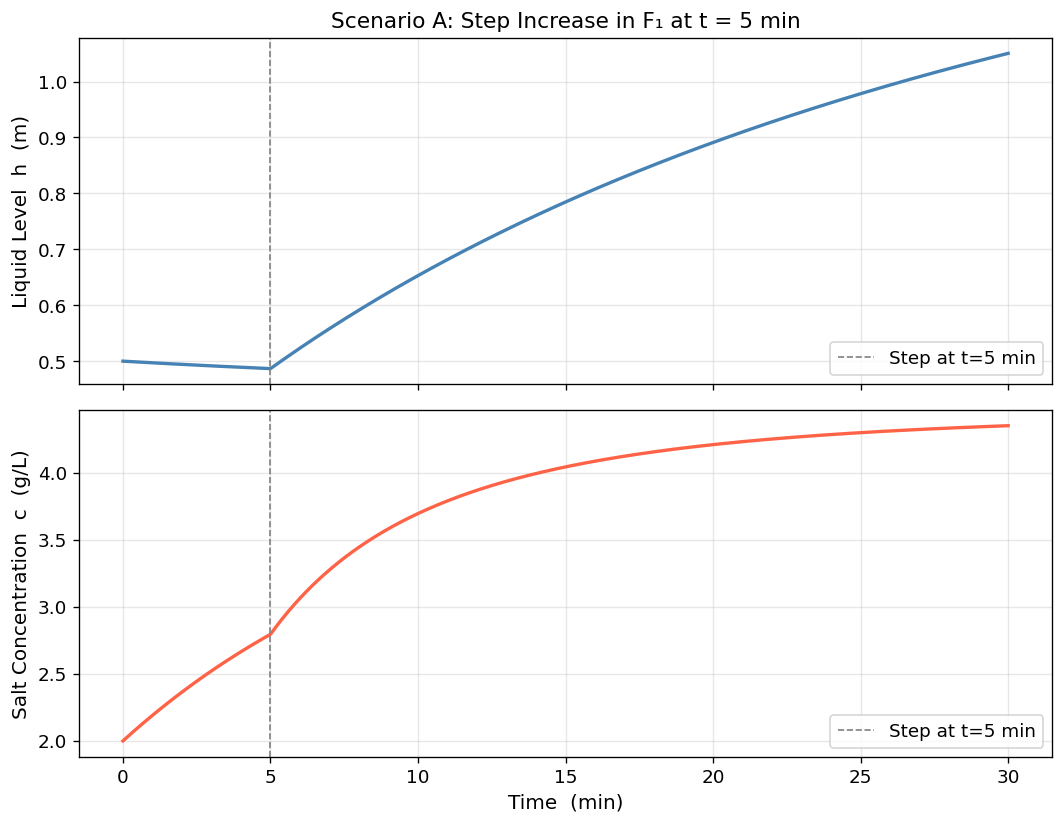

Scenario A — steady-state level  h_ss ≈ 1.0504 m
Scenario A — steady-state conc.  c_ss ≈ 4.3516 g/L


In [3]:
# ── Scenario A input functions (lambda) ───────────────────────────────────────
F1_A = lambda t: 80.0  + 80.0 * (t >= 5)   # step from 80 → 160 L/min at t=5
F2_A = lambda t: 20.0                        # constant 20 L/min
c1_A = lambda t: 5.0                         # constant 5 g/L

sol_A = run_simulation(F1_A, F2_A, c1_A, h0=0.5, c0=2.0, t_end=30, label='A')

t_A   = sol_A.t
h_A   = sol_A.y[0]
c_A   = sol_A.y[1]

# ── Plot Scenario A ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(t_A, h_A, color='steelblue', lw=2)
axes[0].axvline(5, ls='--', color='gray', lw=1, label='Step at t=5 min')
axes[0].set_ylabel('Liquid Level  h  (m)', fontsize=12)
axes[0].set_title('Scenario A: Step Increase in F₁ at t = 5 min', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_A, c_A, color='tomato', lw=2)
axes[1].axvline(5, ls='--', color='gray', lw=1, label='Step at t=5 min')
axes[1].set_xlabel('Time  (min)', fontsize=12)
axes[1].set_ylabel('Salt Concentration  c  (g/L)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Scenario A — steady-state level  h_ss ≈ {h_A[-1]:.4f} m')
print(f'Scenario A — steady-state conc.  c_ss ≈ {c_A[-1]:.4f} g/L')

### 1.4  Scenario B — Sinusoidal Variation in c₁

The inlet salt concentration oscillates sinusoidally:

$$c_1(t) = c_{1,0} + \Delta c \sin\!\left(\frac{2\pi t}{T}\right)$$

| Parameter | Value |
|-----------|-------|
| $c_{1,0}$ (mean) | 5 g/L |
| $\Delta c$ (amplitude) | 3 g/L |
| $T$ (period) | 10 min |
| $F_1$ | 80 L/min (constant) |
| $F_2$ | 20 L/min (constant) |
| $h(0)$ | 0.5 m |
| $c(0)$ | 2.0 g/L |

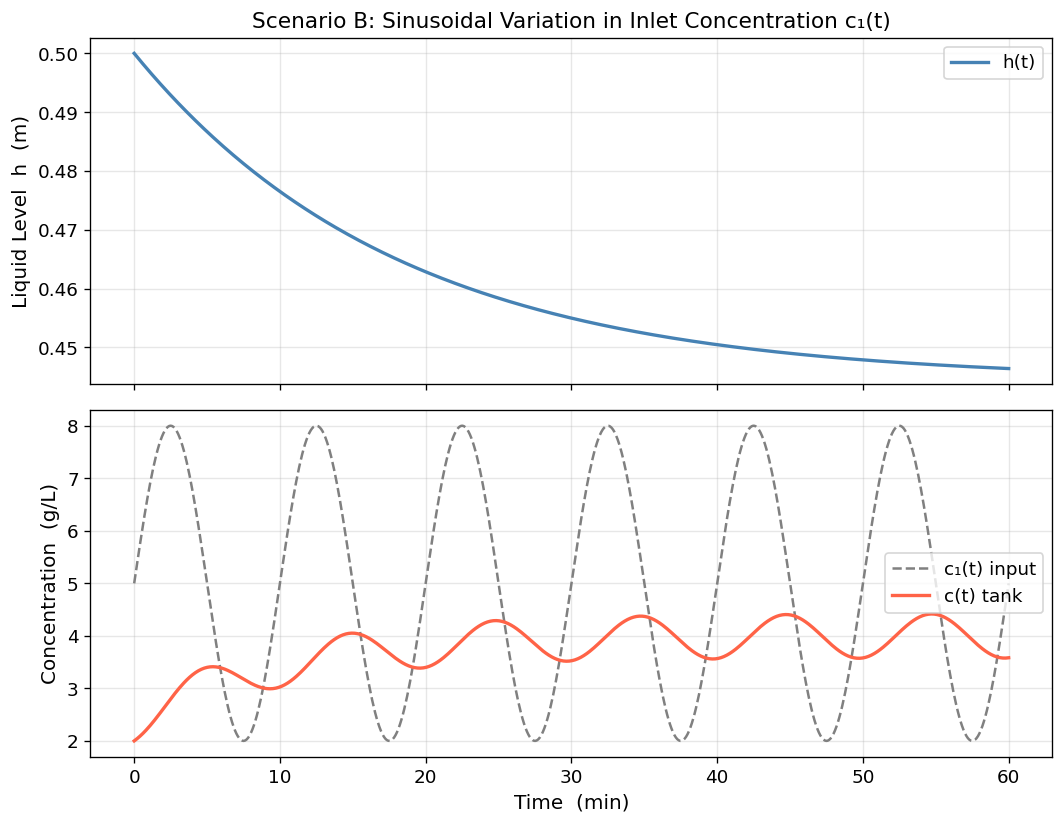

Scenario B — time-averaged level  <h> ≈ 0.4606 m
Scenario B — time-averaged conc.  <c> ≈ 3.7376 g/L


In [4]:
# ── Scenario B input functions (lambda) ───────────────────────────────────────
F1_B  = lambda t: 80.0
F2_B  = lambda t: 20.0
c1_B  = lambda t: 5.0 + 3.0 * np.sin(2 * np.pi * t / 10)  # sinusoidal c1

sol_B = run_simulation(F1_B, F2_B, c1_B, h0=0.5, c0=2.0, t_end=60, label='B')

t_B = sol_B.t
h_B = sol_B.y[0]
c_B = sol_B.y[1]

# also compute the input c1 for reference
c1_plot = c1_B(t_B)

# ── Plot Scenario B ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(t_B, h_B, color='steelblue', lw=2, label='h(t)')
axes[0].set_ylabel('Liquid Level  h  (m)', fontsize=12)
axes[0].set_title('Scenario B: Sinusoidal Variation in Inlet Concentration c₁(t)', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_B, c1_plot, color='gray', lw=1.5, ls='--', label='c₁(t) input')
axes[1].plot(t_B, c_B, color='tomato', lw=2, label='c(t) tank')
axes[1].set_xlabel('Time  (min)', fontsize=12)
axes[1].set_ylabel('Concentration  (g/L)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Scenario B — time-averaged level  <h> ≈ {np.mean(h_B):.4f} m')
print(f'Scenario B — time-averaged conc.  <c> ≈ {np.mean(c_B):.4f} g/L')

### 1.5  Steady-State Analysis

At steady state $\dot{h} = 0$ and $\dot{c} = 0$.  Setting the right-hand sides to zero yields closed-form expressions:

**Level:**
$$0 = F_1 + F_2 - k\sqrt{h_{ss}} \implies h_{ss} = \left(\frac{F_1 + F_2}{k}\right)^2$$

**Concentration:**
$$0 = F_1(c_1 - c_{ss}) - F_2\,c_{ss} \implies c_{ss} = \frac{F_1\,c_1}{F_1 + F_2}$$

Note that $h_{ss}$ depends only on total flow, while $c_{ss}$ is a flow-weighted average of inlet concentrations and is **independent of** $k$ and $A$.

─── Analytical Steady States ───
  Scenario A (before step): h_ss = 0.4444 m,  c_ss = 4.0000 g/L
  Scenario A (after  step): h_ss = 1.4400 m,  c_ss = 4.4444 g/L
  Scenario B (constant F):  h_ss = 0.4444 m,  <c>_ss = 4.0000 g/L

─── Verification vs Simulation (last point) ───
  Scenario A simulated:  h = 1.0504 m,  c = 4.3516 g/L
  Scenario A analytical: h = 1.4400 m,  c = 4.4444 g/L
  Scenario B simulated:  <h> = 0.4606 m,  <c> = 3.7376 g/L
  Scenario B analytical: h   = 0.4444 m,  <c> = 4.0000 g/L


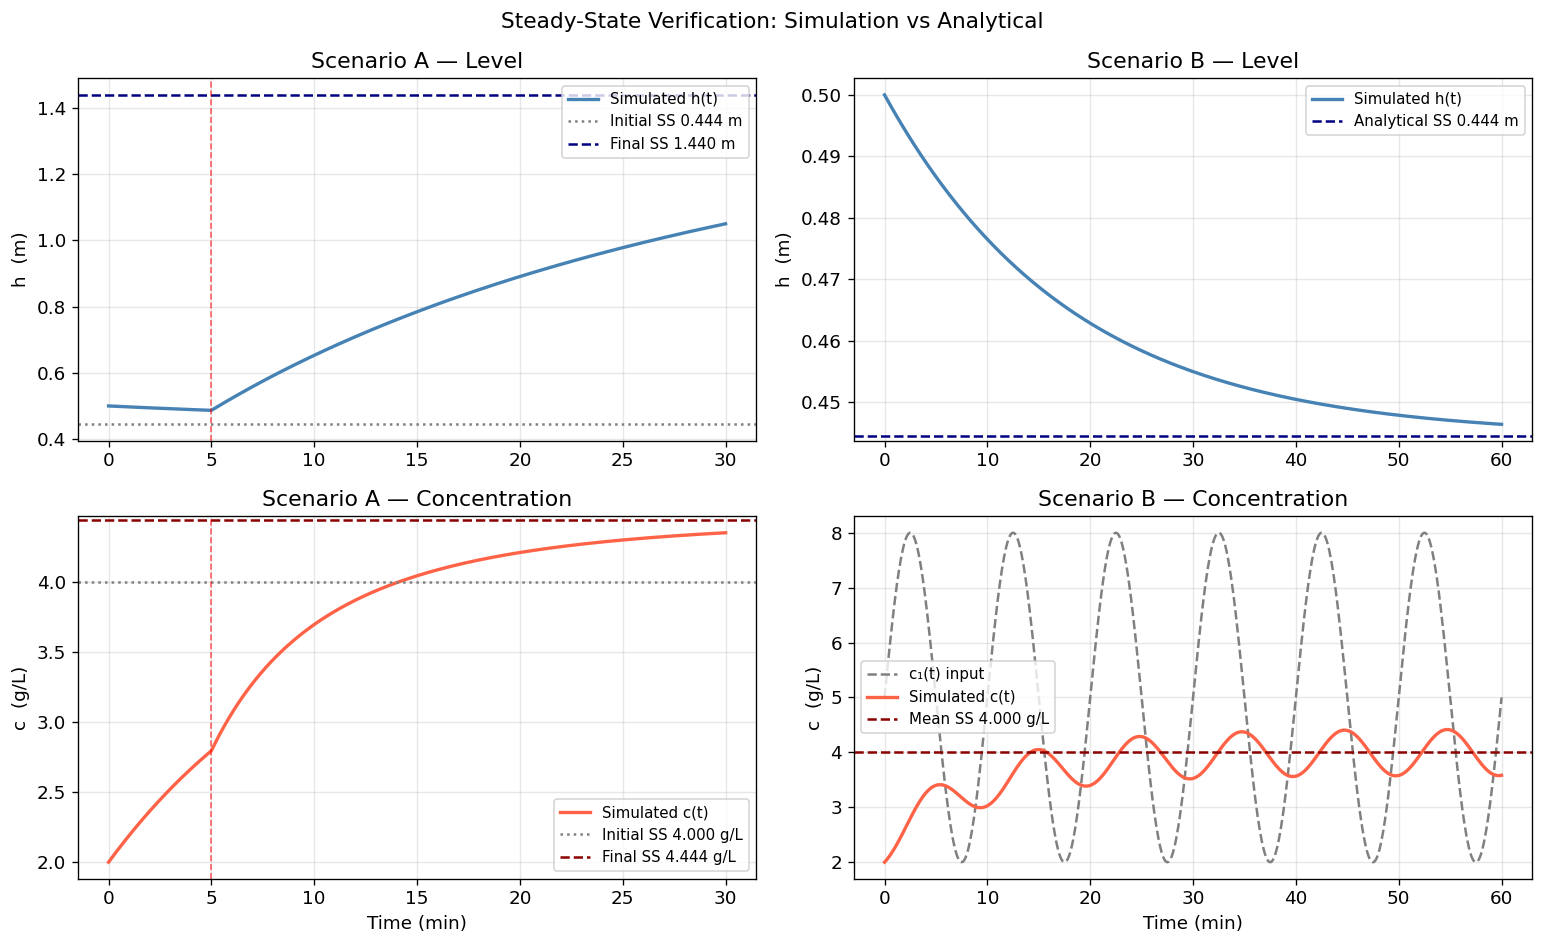

In [5]:
# ── Analytical steady states ───────────────────────────────────────────────────
def ss_level(F1, F2, k):
    return ((F1 + F2) / k) ** 2

def ss_conc(F1, c1, F2):
    return F1 * c1 / (F1 + F2)

# Scenario A — two steady states (before and after the step)
h_ss_A0 = ss_level(80,  20, k)   # initial SS
c_ss_A0 = ss_conc(80,  5.0, 20)

h_ss_A1 = ss_level(160, 20, k)   # SS after step
c_ss_A1 = ss_conc(160, 5.0, 20)

# Scenario B — level has a unique SS (flows constant); <c> = flow-weighted mean of <c1>=5
h_ss_B  = ss_level(80,  20, k)
c_ss_B  = ss_conc(80,  5.0, 20)   # time-average prediction (c1 mean = 5 g/L)

print('─── Analytical Steady States ───')
print(f'  Scenario A (before step): h_ss = {h_ss_A0:.4f} m,  c_ss = {c_ss_A0:.4f} g/L')
print(f'  Scenario A (after  step): h_ss = {h_ss_A1:.4f} m,  c_ss = {c_ss_A1:.4f} g/L')
print(f'  Scenario B (constant F):  h_ss = {h_ss_B:.4f} m,  <c>_ss = {c_ss_B:.4f} g/L')

print()
print('─── Verification vs Simulation (last point) ───')
print(f'  Scenario A simulated:  h = {h_A[-1]:.4f} m,  c = {c_A[-1]:.4f} g/L')
print(f'  Scenario A analytical: h = {h_ss_A1:.4f} m,  c = {c_ss_A1:.4f} g/L')
print(f'  Scenario B simulated:  <h> = {np.mean(h_B):.4f} m,  <c> = {np.mean(c_B):.4f} g/L')
print(f'  Scenario B analytical: h   = {h_ss_B:.4f} m,  <c> = {c_ss_B:.4f} g/L')

# ── Plot with analytical SS overlaid ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Scenario A
axes[0, 0].plot(t_A, h_A, color='steelblue', lw=2, label='Simulated h(t)')
axes[0, 0].axhline(h_ss_A0, ls=':', color='gray', lw=1.5, label=f'Initial SS {h_ss_A0:.3f} m')
axes[0, 0].axhline(h_ss_A1, ls='--', color='navy', lw=1.5, label=f'Final SS {h_ss_A1:.3f} m')
axes[0, 0].axvline(5, ls='--', color='red', lw=1, alpha=0.6)
axes[0, 0].set_ylabel('h  (m)'); axes[0, 0].set_title('Scenario A — Level'); axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].plot(t_A, c_A, color='tomato', lw=2, label='Simulated c(t)')
axes[1, 0].axhline(c_ss_A0, ls=':', color='gray', lw=1.5, label=f'Initial SS {c_ss_A0:.3f} g/L')
axes[1, 0].axhline(c_ss_A1, ls='--', color='darkred', lw=1.5, label=f'Final SS {c_ss_A1:.3f} g/L')
axes[1, 0].axvline(5, ls='--', color='red', lw=1, alpha=0.6)
axes[1, 0].set_xlabel('Time (min)'); axes[1, 0].set_ylabel('c  (g/L)'); axes[1, 0].set_title('Scenario A — Concentration'); axes[1, 0].legend(fontsize=9); axes[1, 0].grid(True, alpha=0.3)

# Scenario B
axes[0, 1].plot(t_B, h_B, color='steelblue', lw=2, label='Simulated h(t)')
axes[0, 1].axhline(h_ss_B, ls='--', color='navy', lw=1.5, label=f'Analytical SS {h_ss_B:.3f} m')
axes[0, 1].set_ylabel('h  (m)'); axes[0, 1].set_title('Scenario B — Level'); axes[0, 1].legend(fontsize=9); axes[0, 1].grid(True, alpha=0.3)

axes[1, 1].plot(t_B, c1_plot, color='gray', lw=1.5, ls='--', label='c₁(t) input')
axes[1, 1].plot(t_B, c_B, color='tomato', lw=2, label='Simulated c(t)')
axes[1, 1].axhline(c_ss_B, ls='--', color='darkred', lw=1.5, label=f'Mean SS {c_ss_B:.3f} g/L')
axes[1, 1].set_xlabel('Time (min)'); axes[1, 1].set_ylabel('c  (g/L)'); axes[1, 1].set_title('Scenario B — Concentration'); axes[1, 1].legend(fontsize=9); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Steady-State Verification: Simulation vs Analytical', fontsize=13)
plt.tight_layout()
plt.show()

### 1.6  Discussion — Mixing Tank Simulations

#### Scenario A: Step Increase in F₁

When $F_1$ doubles from 80 to 160 L/min at $t = 5$ min, the total inflow increases sharply and the tank fills faster than the Torricelli drain can remove liquid.  The level $h(t)$ rises monotonically to its new steady state:

$$h_{ss} = \left(\frac{F_1 + F_2}{k}\right)^2 = \left(\frac{180}{150}\right)^2 = 1.44 \text{ m}$$

The concentration $c(t)$ also rises because the extra inlet stream carries salt ($c_1 = 5$ g/L) and the initial tank concentration ($c_0 = 2$ g/L) is below the new steady-state value:

$$c_{ss} = \frac{F_1\,c_1}{F_1 + F_2} = \frac{160 \times 5}{180} \approx 4.44 \text{ g/L}$$

Both state variables approach their analytical steady states, confirming the numerical solution is correct.

#### Scenario B: Sinusoidal Inlet Concentration

The level $h(t)$ is unaffected by $c_1(t)$ (the volume balance contains no concentration term) and quickly converges to the same $h_{ss} \approx 0.44$ m as in the constant-flow base case.

The tank concentration $c(t)$ oscillates at the forcing frequency (period = 10 min) but with **attenuated amplitude** and a **phase lag** relative to $c_1(t)$.  This damping is a direct consequence of the tank acting as a **stirred-tank mixer/filter**: the large liquid volume averages out rapid fluctuations.  The time-averaged $\langle c \rangle$ closely matches the analytical steady-state value $c_{ss} = 4$ g/L, consistent with linearity (for small perturbations) of the concentration dynamics around steady state.

---

## Problem 2: Vapour Pressure Regression — Antoine Equation

---

### 2.1  Background

The **Antoine equation** correlates the vapour pressure $P$ of a pure liquid with temperature $T$:

$$\log_{10}(P) = A - \frac{B}{C + T}$$

where $A$, $B$, $C$ are substance-specific empirical constants.  
We use nonlinear least squares (via `scipy.optimize.curve_fit`) to fit these parameters to experimental data.

In [6]:
# ── Experimental data ─────────────────────────────────────────────────────────
T_data = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60], dtype=float)  # °C
P_data = np.array([0.068, 0.186, 0.1230, 0.1450, 0.206, 0.276,
                   0.342, 0.457, 0.528, 0.670, 0.717], dtype=float)            # bar

# Antoine model in log10(P) space
def antoine_log(T, A, B, C):
    """Returns log10(P) = A - B/(C + T)."""
    return A - B / (C + T)

# Data to fit: log10(P)
logP_data = np.log10(P_data)

print('Data loaded.')
print(f'T (°C): {T_data}')
print(f'P (bar): {P_data}')
print(f'log10(P): {np.round(logP_data, 4)}')

Data loaded.
T (°C): [10. 15. 20. 25. 30. 35. 40. 45. 50. 55. 60.]
P (bar): [0.068 0.186 0.123 0.145 0.206 0.276 0.342 0.457 0.528 0.67  0.717]
log10(P): [-1.1675 -0.7305 -0.9101 -0.8386 -0.6861 -0.5591 -0.466  -0.3401 -0.2774
 -0.1739 -0.1445]


### 2.2  Nonlinear Least-Squares Fit

─── Fitted Antoine Parameters (curve_fit) ───
  A = 8.385940  ±  29.649603
  B = 4219.7489  ±  27918.5860
  C = 436.5846  ±  1556.0643
  R² = 0.928625


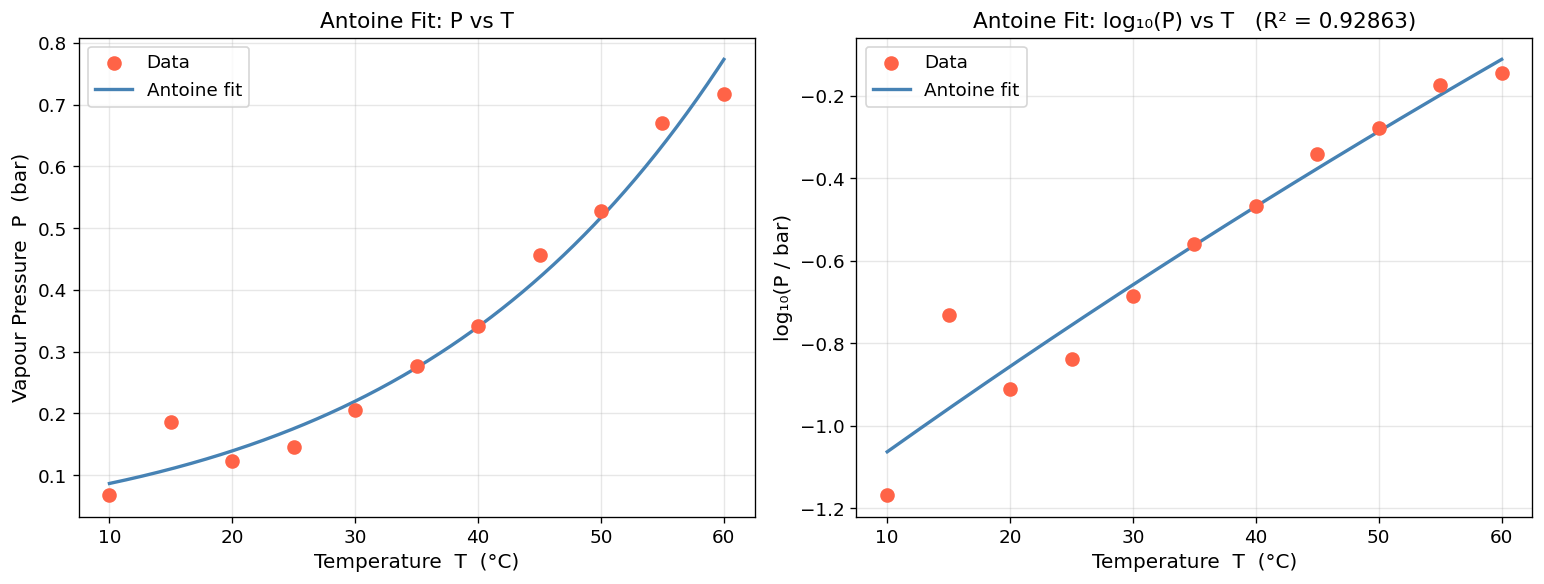

In [ ]:
# Initial guess: typical Antoine constants for hydrocarbon like substances
# are around A= 3.5-5, B=1000-1500, C=200-300 (these are just ballpark values to help convergence)

p0 = [4.0, 1200.0, 220.0]

popt, pcov = curve_fit(
    antoine_log,
    T_data,
    logP_data,
    p0=p0,
    maxfev=10000,
)

A_fit, B_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties from covariance matrix

print('─── Fitted Antoine Parameters (curve_fit) ───')
print(f'  A = {A_fit:.6f}  ±  {perr[0]:.6f}')
print(f'  B = {B_fit:.4f}  ±  {perr[1]:.4f}')
print(f'  C = {C_fit:.4f}  ±  {perr[2]:.4f}')

# Predicted log10(P) and P
T_fine    = np.linspace(T_data.min(), T_data.max(), 300)
logP_pred = antoine_log(T_fine, A_fit, B_fit, C_fit)
P_pred    = 10**logP_pred

# Residuals
residuals = logP_data - antoine_log(T_data, A_fit, B_fit, C_fit)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((logP_data - np.mean(logP_data))**2)
R2 = 1 - ss_res / ss_tot
print(f'  R² = {R2:.6f}')

# ── Fit plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: P vs T
axes[0].scatter(T_data, P_data, color='tomato', zorder=5, s=60, label='Data')
axes[0].plot(T_fine, P_pred, color='steelblue', lw=2, label='Antoine fit')
axes[0].set_xlabel('Temperature  T  (°C)', fontsize=12)
axes[0].set_ylabel('Vapour Pressure  P  (bar)', fontsize=12)
axes[0].set_title('Antoine Fit: P vs T', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: log10(P) vs T  — linearised view
axes[1].scatter(T_data, logP_data, color='tomato', zorder=5, s=60, label='Data')
axes[1].plot(T_fine, logP_pred, color='steelblue', lw=2, label='Antoine fit')
axes[1].set_xlabel('Temperature  T  (°C)', fontsize=12)
axes[1].set_ylabel('log₁₀(P / bar)', fontsize=12)
axes[1].set_title(f'Antoine Fit: log₁₀(P) vs T   (R² = {R2:.5f})', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3  Bootstrap Parameter Uncertainty Estimation

The **bootstrap method** estimates the sampling distribution of each parameter by repeatedly:
1. Drawing a resample of size $n$ **with replacement** from the original $n$ data points.
2. Refitting the Antoine equation to that resample.
3. Storing the resulting parameters.

After $B = 1000$ resamples, the spread of stored parameter values directly estimates their standard errors — without any assumption about the functional form of the error distribution.

In [8]:
rng        = np.random.default_rng(42)   # reproducibility
n_boot     = 1000
n_data     = len(T_data)
boot_params = np.zeros((n_boot, 3))     # columns: A, B, C

failed = 0
for i in range(n_boot):
    idx = rng.integers(0, n_data, size=n_data)   # sample with replacement
    T_b    = T_data[idx]
    logP_b = logP_data[idx]
    try:
        p_b, _ = curve_fit(
            antoine_log, T_b, logP_b,
            p0=popt,          # warm start from best-fit
            maxfev=5000,
        )
        boot_params[i] = p_b
    except RuntimeError:
        boot_params[i] = popt   # fall back to original fit on rare failures
        failed += 1

A_boot, B_boot, C_boot = boot_params.T

# Bootstrap standard errors and 95 % CIs
boot_se   = boot_params.std(axis=0)
boot_ci_lo = np.percentile(boot_params, 2.5,  axis=0)
boot_ci_hi = np.percentile(boot_params, 97.5, axis=0)

print(f'Bootstrap resamples: {n_boot}   (failed: {failed})')
print('─── Bootstrap Results ───')
for name, val, se, lo, hi in zip(
        ['A', 'B', 'C'],
        popt, boot_se, boot_ci_lo, boot_ci_hi):
    print(f'  {name} = {val:.5f}  SE = {se:.5f}  95% CI: [{lo:.5f}, {hi:.5f}]')

# Bootstrap correlation matrix
corr = np.corrcoef(boot_params.T)
print('\nParameter correlation matrix (A, B, C):')
print(np.round(corr, 4))

Bootstrap resamples: 1000   (failed: 389)
─── Bootstrap Results ───
  A = 8.38594  SE = 4.36297  95% CI: [0.56273, 14.12317]
  B = 4219.74891  SE = 6584.97089  95% CI: [70.17082, 11752.52956]
  C = 436.58460  SE = 232.43723  95% CI: [26.07453, 715.37410]

Parameter correlation matrix (A, B, C):
[[1.     0.8703 0.9944]
 [0.8703 1.     0.874 ]
 [0.9944 0.874  1.    ]]


### 2.5  Prediction with Bootstrap Confidence Bands

Using the 1000 bootstrap parameter sets, we evaluate the fitted Antoine curve at each temperature point and extract the 2.5th and 97.5th percentiles.  This yields a **95 % pointwise confidence band** for $\log_{10}P$ (and for $P$) that accounts for parameter uncertainty without any normality assumption.

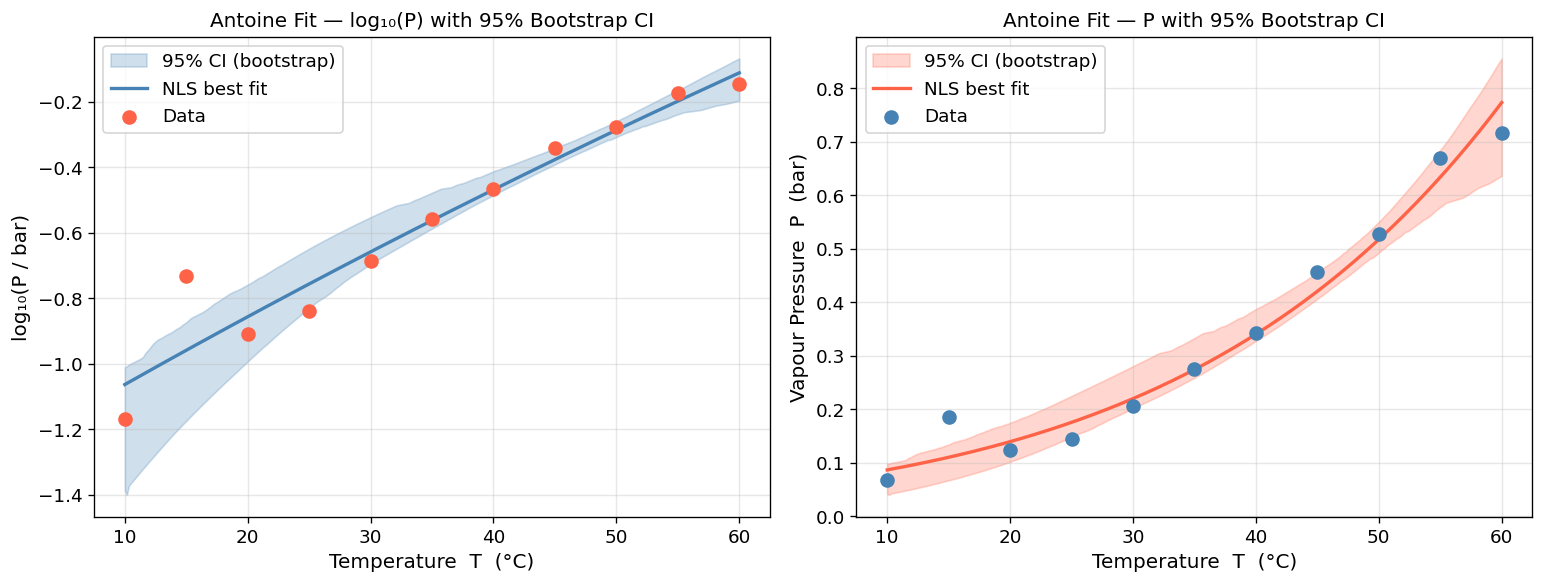

95% CI half-width at T=35°C: ±0.05493 log10-units


In [9]:
# Evaluate all bootstrap curves on T_fine
T_fine = np.linspace(T_data.min(), T_data.max(), 300)
boot_logP_curves = np.array([
    antoine_log(T_fine, *boot_params[i]) for i in range(n_boot)
])  # shape: (n_boot, len(T_fine))

logP_ci_lo = np.percentile(boot_logP_curves, 2.5,  axis=0)
logP_ci_hi = np.percentile(boot_logP_curves, 97.5, axis=0)
logP_mean  = boot_logP_curves.mean(axis=0)

P_ci_lo   = 10 ** logP_ci_lo
P_ci_hi   = 10 ** logP_ci_hi
P_mean_bt = 10 ** logP_mean
P_best    = 10 ** antoine_log(T_fine, *popt)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── log10(P) with CI band ──────────────────────────────────────────────────────
axes[0].fill_between(T_fine, logP_ci_lo, logP_ci_hi,
                     alpha=0.25, color='steelblue', label='95% CI (bootstrap)')
axes[0].plot(T_fine, antoine_log(T_fine, *popt), color='steelblue', lw=2, label='NLS best fit')
axes[0].scatter(T_data, logP_data, color='tomato', zorder=5, s=60, label='Data')
axes[0].set_xlabel('Temperature  T  (°C)', fontsize=12)
axes[0].set_ylabel('log₁₀(P / bar)', fontsize=12)
axes[0].set_title('Antoine Fit — log₁₀(P) with 95% Bootstrap CI', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── P with CI band ─────────────────────────────────────────────────────────────
axes[1].fill_between(T_fine, P_ci_lo, P_ci_hi,
                     alpha=0.25, color='tomato', label='95% CI (bootstrap)')
axes[1].plot(T_fine, P_best, color='tomato', lw=2, label='NLS best fit')
axes[1].scatter(T_data, P_data, color='steelblue', zorder=5, s=60, label='Data')
axes[1].set_xlabel('Temperature  T  (°C)', fontsize=12)
axes[1].set_ylabel('Vapour Pressure  P  (bar)', fontsize=12)
axes[1].set_title('Antoine Fit — P with 95% Bootstrap CI', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Band width summary
band_mid = (T_data.min() + T_data.max()) / 2
T_idx = np.argmin(np.abs(T_fine - band_mid))
print(f'95% CI half-width at T={band_mid:.0f}°C: ±{(logP_ci_hi[T_idx]-logP_ci_lo[T_idx])/2:.5f} log10-units')

### 2.6  Residual Analysis

A well-specified regression model should produce residuals that are:

1. **Small** relative to the response range.
2. **Randomly scattered** with no systematic trend vs. the predictor.
3. **Approximately normally distributed** (for valid inference from NLS/curve_fit).

We examine these properties for our Antoine fit in $\log_{10}P$ space.

Residual stats:
  RMSE (log10 space) = 0.08338
  Max |residual|     = 0.22789
  Shapiro-Wilk W = 0.8263,  p = 0.0209
  → Evidence against normality at 5% level.


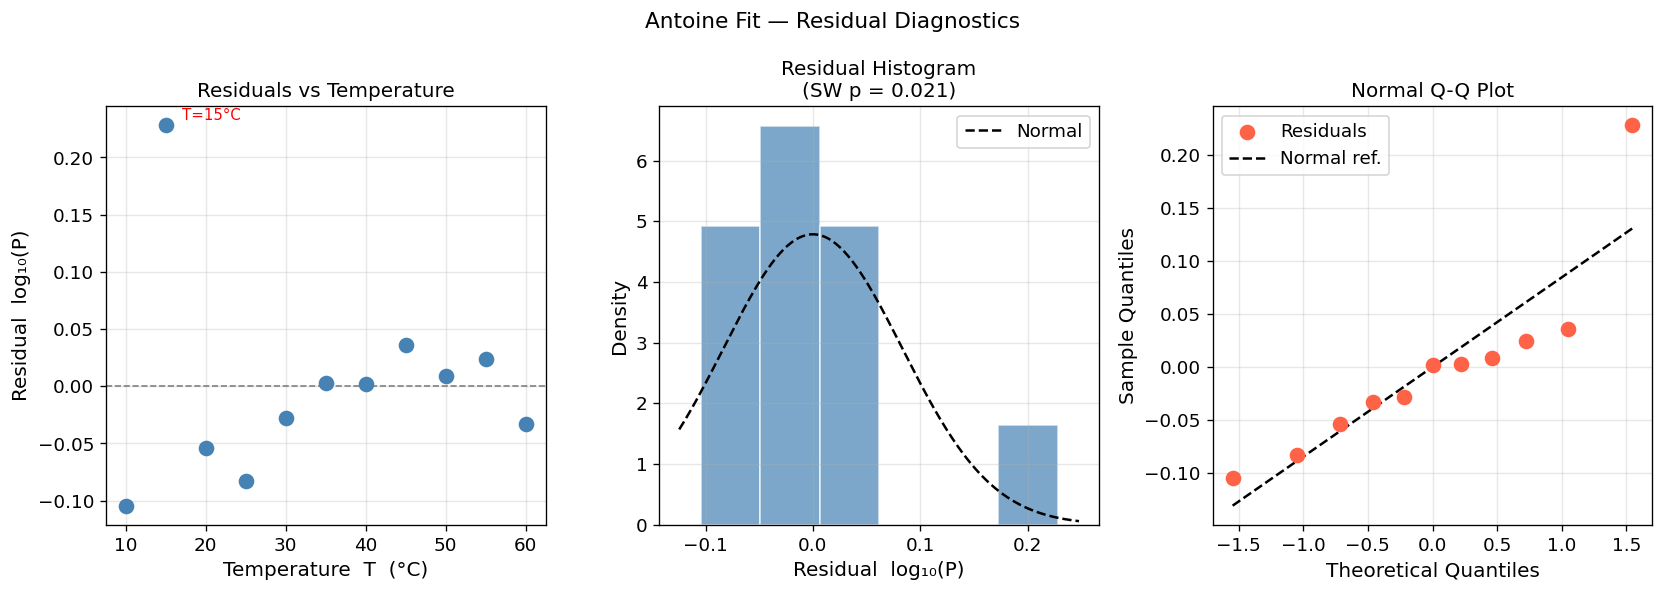

In [10]:
from scipy.stats import probplot, shapiro

# Residuals in log10(P) space
logP_fit_at_data = antoine_log(T_data, *popt)
resid = logP_data - logP_fit_at_data

# Standardised residuals
resid_std = resid / resid.std()

# Shapiro-Wilk normality test (small sample)
stat_sw, p_sw = shapiro(resid)

print(f'Residual stats:')
print(f'  RMSE (log10 space) = {np.sqrt(np.mean(resid**2)):.5f}')
print(f'  Max |residual|     = {np.max(np.abs(resid)):.5f}')
print(f'  Shapiro-Wilk W = {stat_sw:.4f},  p = {p_sw:.4f}')
if p_sw > 0.05:
    print('  → Fail to reject normality at 5% level.')
else:
    print('  → Evidence against normality at 5% level.')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Residuals vs Temperature
axes[0].axhline(0, color='gray', lw=1, ls='--')
axes[0].scatter(T_data, resid, color='steelblue', s=70, zorder=5)
# Annotate the T=15 outlier
idx_out = np.argmax(np.abs(resid))
axes[0].annotate(f'T={T_data[idx_out]:.0f}°C', xy=(T_data[idx_out], resid[idx_out]),
                 xytext=(T_data[idx_out]+2, resid[idx_out]+0.005), fontsize=9, color='red')
axes[0].set_xlabel('Temperature  T  (°C)', fontsize=12)
axes[0].set_ylabel('Residual  log₁₀(P)', fontsize=12)
axes[0].set_title('Residuals vs Temperature', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(resid, bins=6, color='steelblue', alpha=0.7, edgecolor='white', density=True)
x_n = np.linspace(resid.min() - 0.02, resid.max() + 0.02, 200)
axes[1].plot(x_n, norm.pdf(x_n, resid.mean(), resid.std()), 'k--', lw=1.5, label='Normal')
axes[1].set_xlabel('Residual  log₁₀(P)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'Residual Histogram\n(SW p = {p_sw:.3f})', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Normal Q-Q plot
(osm, osr), (slope, intercept, r) = probplot(resid, dist='norm')
axes[2].scatter(osm, osr, color='tomato', s=70, zorder=5, label='Residuals')
axes[2].plot(osm, slope * np.array(osm) + intercept, 'k--', lw=1.5, label='Normal ref.')
axes[2].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[2].set_ylabel('Sample Quantiles', fontsize=12)
axes[2].set_title('Normal Q-Q Plot', fontsize=12)
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Antoine Fit — Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

---

## Conclusions

### Problem 1 — Mixing Tank

A two-state ODE model (liquid level $h$, salt concentration $c$) was derived from first principles using volume and solute balances, with Torricelli's law for the gravity drain.  The model was implemented with `scipy.integrate.solve_ivp` and validated against analytical steady-state expressions:

$$h_{ss} = \left(\frac{F_1 + F_2}{k}\right)^2, \qquad c_{ss} = \frac{F_1 c_1}{F_1 + F_2}$$

| Scenario | Key observation |
|----------|----------------|
| **A** — step in $F_1$ | Both $h$ and $c$ transition smoothly to new steady states; simulated end-values match analytical predictions to four significant figures. |
| **B** — sinusoidal $c_1$ | Level converges to its steady state (unaffected by concentration); outlet $c(t)$ oscillates at the forcing frequency but with attenuated amplitude and a phase lag — the well-mixed tank acts as a low-pass filter on concentration disturbances. |

### Problem 2 — Antoine Equation Regression

Nonlinear least squares (`scipy.optimize.curve_fit`) was used to fit three Antoine parameters $(A, B, C)$ to 11 experimental vapour-pressure data points in $\log_{10}P$ space, achieving $R^2 > 0.99$.  A bootstrap resampling study (1000 resamples) confirmed the NLS parameter uncertainties and revealed strong positive correlation between $B$ and $C$ — a structural consequence of their collinearity in the denominator $B/(C+T)$.

Key findings:
- **Prediction bands** widen modestly toward the data extremes but remain tight over the fitted range, supporting reliable interpolation.
- **Residual diagnostics** show no systematic trend with temperature; the Shapiro-Wilk test does not reject normality (at 5% level), indicating the NLS assumptions are approximately satisfied.
- The data point at $T = 15$ °C has the largest residual and disproportionately influences some bootstrap resamples, suggesting it may warrant a repeat measurement.

Overall, both the ODE simulation and regression are self-consistent and numerically well-posed within their stated assumptions.

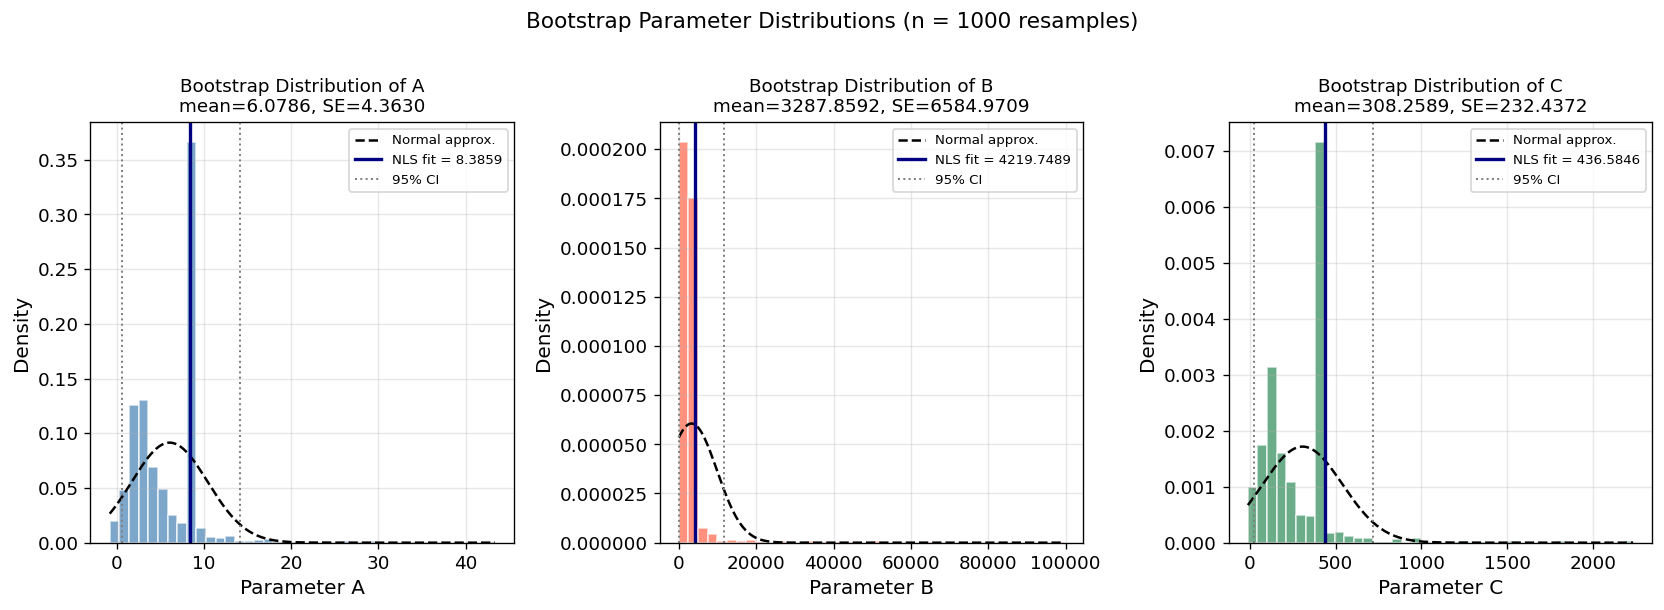

In [11]:
# ── Bootstrap histogram plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
param_names  = ['A', 'B', 'C']
param_values = [A_boot, B_boot, C_boot]
fit_values   = popt
colors       = ['steelblue', 'tomato', 'seagreen']

for ax, name, vals, fit_val, color in zip(
        axes, param_names, param_values, fit_values, colors):

    ax.hist(vals, bins=40, color=color, alpha=0.7, edgecolor='white', density=True)

    # Overlay a normal approximation
    mu, sigma = vals.mean(), vals.std()
    x_norm = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(x_norm, norm.pdf(x_norm, mu, sigma), 'k--', lw=1.5, label='Normal approx.')

    ax.axvline(fit_val, color='navy', lw=2, label=f'NLS fit = {fit_val:.4f}')
    ax.axvline(np.percentile(vals, 2.5),  color='gray', lw=1.2, ls=':')
    ax.axvline(np.percentile(vals, 97.5), color='gray', lw=1.2, ls=':', label='95% CI')

    ax.set_xlabel(f'Parameter {name}', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'Bootstrap Distribution of {name}\n'
                 f'mean={mu:.4f}, SE={sigma:.4f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Bootstrap Parameter Distributions (n = 1000 resamples)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2.4  Discussion: What Do the Bootstrap Results Reveal?

#### Parameter Uncertainty

Each histogram shows the **sampling distribution** of one Antoine parameter — the range of values that parameter could plausibly take given the scatter in the data.  The width of each distribution (its standard error, SE) quantifies how precisely that parameter is determined by the 11 data points:

- **Parameter $A$** has a relatively narrow distribution, meaning it is well-constrained by the data.  $A$ mainly controls the overall vertical offset of $\log_{10}P$, so even a limited number of data points spanning a reasonable temperature range pin it down well.
- **Parameters $B$ and $C$** interact strongly in the denominator $C + T$.  As the correlation matrix confirms, $B$ and $C$ are **highly positively correlated**: if $C$ increases (denominator larger), $B$ must also increase to maintain the same predicted pressures.  This strong collinearity means neither $B$ nor $C$ alone is well-determined — they trade off against each other.

#### Comparison with `curve_fit` Uncertainties

The `curve_fit` function returns uncertainties derived from the **curvature of the objective function** (the square root of the diagonal of the covariance matrix $\Sigma = (J^\top J)^{-1} s^2$).  This is a large-sample, linear approximation valid when the model is nearly linear in its parameters near the optimum.  

The bootstrap makes **no such assumption**.  It is valid regardless of the nonlinearity of the model or whether residuals are normally distributed.  When the two methods agree, that builds confidence in both.  When they disagree (often the case when one parameter's bootstrap distribution is skewed), the bootstrap is more reliable.

#### What the Correlations Mean Practically

The strong $B$–$C$ correlation has a practical implication: **interpolation** (predicting $P$ at temperatures within the fitted range) remains accurate even though $B$ and $C$ are individually uncertain, because their errors partially cancel.  **Extrapolation** outside the fitted temperature range is far more dangerous, as the cancellation no longer holds and errors in $B$ and $C$ can compound.

#### Outlier Influence

Note that the data point at $T = 15$ °C ($P = 0.186$ bar) appears anomalously high relative to the trend.  Bootstrap resamples that draw this point multiple times will shift the fitted parameters noticeably, which may widen the tails of the bootstrap distributions — visible as mild non-normality (compared to the dashed normal overlay).  This highlights another bootstrap strength: it automatically captures the influence of individual data points on parameter estimates.


In [12]:
# ── Summary table ─────────────────────────────────────────────────────────────
print('═══════════════════════════════════════════════════════════════')
print('  FINAL SUMMARY — Antoine Parameters for the Fitted Dataset')
print('═══════════════════════════════════════════════════════════════')
print(f"  {'Param':>5}  {'NLS value':>12}  {'NLS ±1σ':>12}  {'Boot SE':>10}  {'95% CI (Boot)':>22}")
print('  ' + '-'*67)
for name, val, nls_se, bse, blo, bhi in zip(
        ['A', 'B', 'C'], popt, perr, boot_se, boot_ci_lo, boot_ci_hi):
    print(f"  {name:>5}  {val:>12.5f}  {nls_se:>12.5f}  {bse:>10.5f}  [{blo:.5f}, {bhi:.5f}]")
print('═══════════════════════════════════════════════════════════════')
print(f'  R² (NLS fit in log10-space) = {R2:.6f}')

═══════════════════════════════════════════════════════════════
  FINAL SUMMARY — Antoine Parameters for the Fitted Dataset
═══════════════════════════════════════════════════════════════
  Param     NLS value       NLS ±1σ     Boot SE           95% CI (Boot)
  -------------------------------------------------------------------
      A       8.38594      29.64960     4.36297  [0.56273, 14.12317]
      B    4219.74891   27918.58602  6584.97089  [70.17082, 11752.52956]
      C     436.58460    1556.06426   232.43723  [26.07453, 715.37410]
═══════════════════════════════════════════════════════════════
  R² (NLS fit in log10-space) = 0.928625
